In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

In [ ]:
df_full = pd.read_csv('indian_pharmaceutical_products_clean.csv')
print(df_full.shape)

(253973, 15)


In [ ]:
df = df_full.sample(n=8000, random_state=42).reset_index(drop=True)
print(df.shape)
df.head()

(8000, 15)


,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
0,147739,Mycodryl Syrup,Santiago Lifesciences Pvt Ltd,42.0,False,syrup,100.0,bottle,2,Ammonium Chloride,138mg/5ml,"[{'name': 'Ammonium Chloride', 'strength': '13...",other,bottle of 100 ml Syrup,Santiago Lifesciences Pvt Ltd
1,234400,Vildapin 50mg Tablet,Manith Healthcare Pvt Ltd,120.0,False,tablet,15.0,strip,1,Vildagliptin,50mg,"[{'name': 'Vildagliptin', 'strength': '50mg', ...",other,strip of 15 tablets,Manith Healthcare Pvt Ltd
2,177884,Propol 20mg Tablet,Lifecare Neuro Products Ltd,27.0,False,tablet,10.0,strip,1,Propranolol,20mg,"[{'name': 'Propranolol', 'strength': '20mg', '...",other,strip of 10 tablets,Lifecare Neuro Products Ltd
3,32579,B Cef DS Syrup,Welisynth Pharmaceuticals,52.0,False,syrup,30.0,bottle,1,Cefixime,50mg/5ml,"[{'name': 'Cefixime', 'strength': '50mg/5ml', ...",antibiotic,bottle of 30 ml Syrup,Welisynth Pharmaceuticals
4,49479,Chophos 200mg Injection,Intas Pharmaceuticals Ltd,45.0,False,injection,NaN,NaN,1,Cyclophosphamide,200mg,"[{'name': 'Cyclophosphamide', 'strength': '200...",other,vial of 1 Injection,Intas Pharmaceuticals Ltd


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_id              8000 non-null   int64  
 1   brand_name              8000 non-null   object 
 2   manufacturer            8000 non-null   object 
 3   price_inr               8000 non-null   float64
 4   is_discontinued         8000 non-null   bool   
 5   dosage_form             8000 non-null   object 
 6   pack_size               7276 non-null   float64
 7   pack_unit               7276 non-null   object 
 8   num_active_ingredients  8000 non-null   int64  
 9   primary_ingredient      8000 non-null   object 
 10  primary_strength        7198 non-null   object 
 11  active_ingredients      8000 non-null   object 
 12  therapeutic_class       8000 non-null   object 
 13  packaging_raw           8000 non-null   object 
 14  manufacturer_raw        8000 non-null   

In [ ]:
df.describe()

,product_id,price_inr,pack_size,num_active_ingredients
count,8000.000000,8000.000000,7276.000000,8000.000000
mean,128053.352625,236.782912,19.226223,1.450875
std,73627.910312,1539.450610,34.042637,0.497612
min,42.000000,1.250000,1.000000,1.000000
25%,64920.750000,48.000000,10.000000,1.000000
50%,128392.000000,79.000000,10.000000,1.000000
75%,191689.250000,139.212500,10.000000,2.000000
max,253947.000000,66156.250000,500.000000,2.000000


In [ ]:
print("Missing values-\n")
print(df.isnull().sum())

Missing values-

product_id                  0
brand_name                  0
manufacturer                0
price_inr                   0
is_discontinued             0
dosage_form                 0
pack_size                 724
pack_unit                 724
num_active_ingredients      0
primary_ingredient          0
primary_strength          802
active_ingredients          0
therapeutic_class           0
packaging_raw               0
manufacturer_raw            0
dtype: int64


In [ ]:
df = df[df['price_inr'] > 0].reset_index(drop=True)
print(df.shape)

(8000, 15)


In [ ]:
print(df['active_ingredients'].iloc[0])
print(type(df['active_ingredients'].iloc[0]))

[{'name': 'Ammonium Chloride', 'strength': '138mg/5ml', 'full_description': 'Ammonium Chloride (138mg/5ml)'}, {'name': 'Sodium Citrate', 'strength': '57.03mg/5ml', 'full_description': 'Sodium Citrate (57.03mg/5ml)'}]
<class 'str'>


In [ ]:
def clean_ingredient_name(name):
    name = name.lower().strip()
    name = name.replace('/', ' ').replace('-', ' ')
    name = ' '.join(name.split())
    return name

def clean_strength(strength):
    if pd.isna(strength):
        return ''
    strength = strength.lower().strip().replace(' ', '')
    return strength

def build_cleaned_composition(raw):
    try:
        ingredients = ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        return ''
    parts = []
    for ing in ingredients:
        name = clean_ingredient_name(ing.get('name', ''))
        strength = clean_strength(ing.get('strength', ''))
        parts.append(f"{name}_{strength}")
    parts.sort()
    return '+'.join(parts)

df['cleaned_composition'] = df['active_ingredients'].apply(build_cleaned_composition)
df[['active_ingredients', 'cleaned_composition']].head(10)

,active_ingredients,cleaned_composition
0,"[{'name': 'Ammonium Chloride', 'strength': '13...",ammonium chloride_138mg/5ml+sodium citrate_57....
1,"[{'name': 'Vildagliptin', 'strength': '50mg', ...",vildagliptin_50mg
2,"[{'name': 'Propranolol', 'strength': '20mg', '...",propranolol_20mg
3,"[{'name': 'Cefixime', 'strength': '50mg/5ml', ...",cefixime_50mg/5ml
4,"[{'name': 'Cyclophosphamide', 'strength': '200...",cyclophosphamide_200mg
5,"[{'name': 'Ceftriaxone', 'strength': '1000mg',...",ceftriaxone_1000mg
6,"[{'name': 'Nimesulide', 'strength': '50mg', 'f...",nimesulide_50mg+paracetamol_125mg
7,"[{'name': 'Amoxycillin', 'strength': '400mg/5m...",amoxycillin_400mg/5ml+clavulanic acid_57mg/5ml
8,"[{'name': 'Fenofibrate', 'strength': '160mg', ...",fenofibrate_160mg+rosuvastatin_10mg
9,"[{'name': 'Amoxycillin', 'strength': '200mg', ...",amoxycillin_200mg+clavulanic acid_28.5mg


In [ ]:
print("Unique raw active_ingredients strings:", df['active_ingredients'].nunique())
print("Unique cleaned_composition values:", df['cleaned_composition'].nunique())

Unique raw active_ingredients strings: 2154
Unique cleaned_composition values: 1998


In [ ]:
comp_counts = df['cleaned_composition'].value_counts()
print(comp_counts.head(10))

cleaned_composition
aceclofenac_100mg+paracetamol_325mg        155
levocetirizine_5mg+montelukast_10mg         92
amoxycillin_500mg+clavulanic acid_125mg     89
domperidone_30mg+rabeprazole_20mg           84
pantoprazole_40mg                           79
ofloxacin_200mg+ornidazole_500mg            65
domperidone_30mg+pantoprazole_40mg          64
rabeprazole_20mg                            62
deflazacort_6mg                             59
levocetirizine_5mg                          59
Name: count, dtype: int64


In [ ]:
top_comp = comp_counts.index[0]
sample = df[df['cleaned_composition'] == top_comp][['brand_name', 'manufacturer', 'price_inr']].sort_values('price_inr')
print(f"Composition: {top_comp}")
sample.head(10)

Composition: aceclofenac_100mg+paracetamol_325mg


,brand_name,manufacturer,price_inr
2856,Ulnac-P 100mg/325mg Tablet,Ultra Bio Labs,19.00
63,Levenac P 100mg/325mg Tablet,Levenr Pharma,29.00
3807,Spin-APM Tablet,Makers Laboratories Ltd,29.25
1655,Cimnic-SP Tablet,Arnigeno Life Sciences Private Limited,30.00
5919,Nanofen P 100mg/325mg Tablet,Achilles Healthcare Pvt Ltd,30.00
3412,Acenip 100 mg/325 mg Tablet,Divine Lifecare Pvt Ltd,32.00
3109,Acezion 100mg/325mg Tablet,Zion Pharmaceuticals Pvt Ltd,33.00
5036,Zelofenac 100mg/325mg Tablet,Zenicure Labs,34.00
7411,Nacease P 100mg/325mg Tablet,Kiran Pharmaceutical,34.00
6796,AQT P 100mg/325mg Tablet,Quantum Formulations,34.00


In [ ]:
print("Unique manufacturers:", df['manufacturer'].nunique())
print("Unique dosage forms:", df['dosage_form'].nunique())
print("Unique therapeutic classes:", df['therapeutic_class'].nunique())

Unique manufacturers: 2964
Unique dosage forms: 15
Unique therapeutic classes: 11


In [ ]:
le_manufacturer = LabelEncoder()
df['manufacturer_encoded'] = le_manufacturer.fit_transform(df['manufacturer'])

df = pd.get_dummies(df, columns=['dosage_form', 'therapeutic_class'], prefix=['form', 'class'])
df.head()

,product_id,brand_name,manufacturer,price_inr,is_discontinued,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,...,class_antacid,class_antibiotic,class_antidepressant,class_antidiabetic,class_antihistamine,class_antihypertensive,class_bronchodilator,class_corticosteroid,class_diuretic,class_other
0,147739,Mycodryl Syrup,Santiago Lifesciences Pvt Ltd,42.0,False,100.0,bottle,2,Ammonium Chloride,138mg/5ml,...,False,False,False,False,False,False,False,False,False,True
1,234400,Vildapin 50mg Tablet,Manith Healthcare Pvt Ltd,120.0,False,15.0,strip,1,Vildagliptin,50mg,...,False,False,False,False,False,False,False,False,False,True
2,177884,Propol 20mg Tablet,Lifecare Neuro Products Ltd,27.0,False,10.0,strip,1,Propranolol,20mg,...,False,False,False,False,False,False,False,False,False,True
3,32579,B Cef DS Syrup,Welisynth Pharmaceuticals,52.0,False,30.0,bottle,1,Cefixime,50mg/5ml,...,False,True,False,False,False,False,False,False,False,False
4,49479,Chophos 200mg Injection,Intas Pharmaceuticals Ltd,45.0,False,NaN,NaN,1,Cyclophosphamide,200mg,...,False,False,False,False,False,False,False,False,False,True


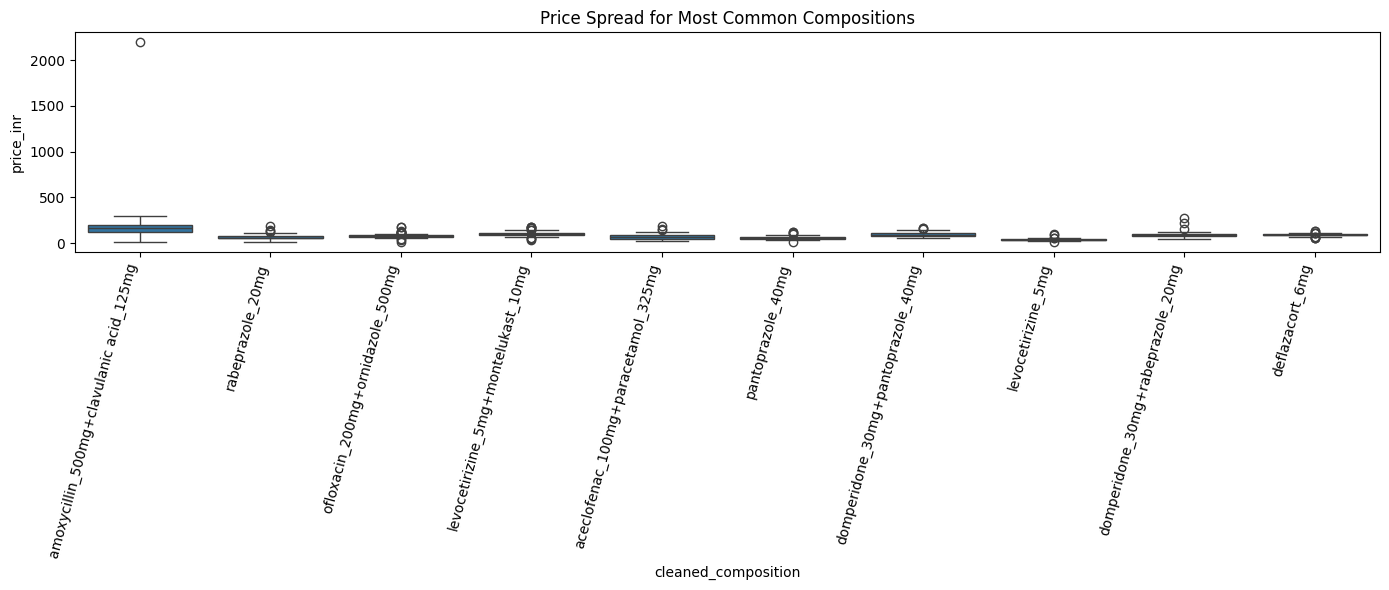

In [ ]:
top10_comps = df['cleaned_composition'].value_counts().head(10).index
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['cleaned_composition'].isin(top10_comps)], x='cleaned_composition', y='price_inr')
plt.xticks(rotation=75, ha='right')
plt.title('Price Spread for Most Common Compositions')
plt.tight_layout()
plt.show()

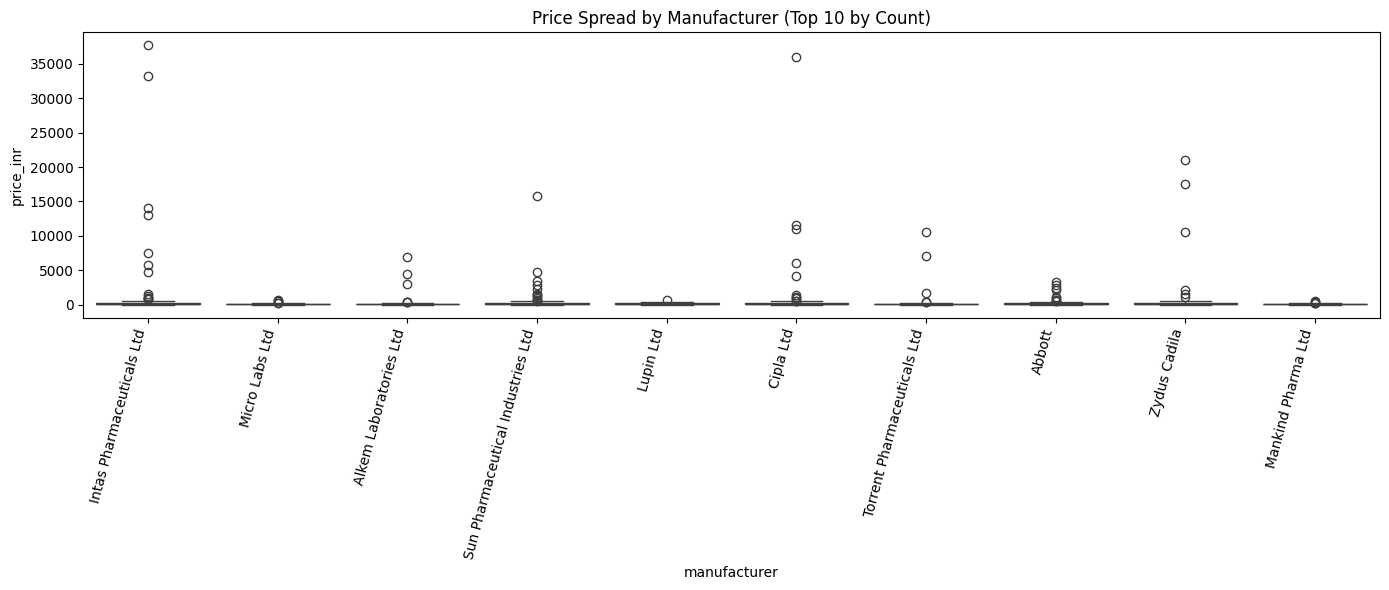

In [ ]:
top10_manu = df['manufacturer'].value_counts().head(10).index
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['manufacturer'].isin(top10_manu)], x='manufacturer', y='price_inr')
plt.xticks(rotation=75, ha='right')
plt.title('Price Spread by Manufacturer (Top 10 by Count)')
plt.tight_layout()
plt.show()

In [ ]:
print("Discontinued rows:", df['is_discontinued'].sum())
df = df[df['is_discontinued'] == False].reset_index(drop=True)

Discontinued rows: 256


In [ ]:
price_cap = df['price_inr'].quantile(0.99)
print(f"Capping at 99th percentile: ₹{price_cap:.2f}")
df = df[df['price_inr'] <= price_cap].reset_index(drop=True)
print(df.shape)

Capping at 99th percentile: ₹2900.00
(7667, 41)


In [ ]:
le_composition = LabelEncoder()
df['composition_encoded'] = le_composition.fit_transform(df['cleaned_composition'])

feature_cols = ['composition_encoded', 'manufacturer_encoded', 'num_active_ingredients', 'pack_size'] + \
               [c for c in df.columns if c.startswith('form_') or c.startswith('class_')]

X = df[feature_cols].fillna(0)
y = df['price_inr']
print(X.shape)
X.head()

(7667, 30)


,composition_encoded,manufacturer_encoded,num_active_ingredients,pack_size,form_capsule,form_cream,form_drops,form_gel,form_inhaler,form_injection,...,class_antacid,class_antibiotic,class_antidepressant,class_antidiabetic,class_antihistamine,class_antihypertensive,class_bronchodilator,class_corticosteroid,class_diuretic,class_other
0,152,2321,2,100.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1855,1575,1,15.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1623,1487,1,10.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,422,2826,1,30.0,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,685,1270,1,0.0,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (6133, 30)
X_test shape: (1534, 30)


In [ ]:
model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Random Forest MAE: ₹{mae:.2f}")

Random Forest MAE: ₹62.50


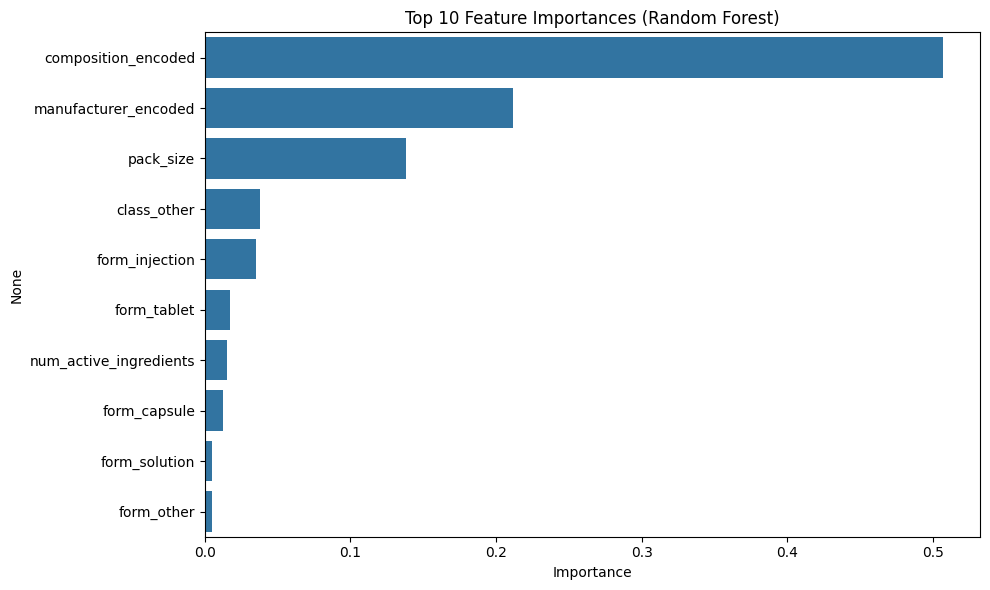

In [ ]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [35]:
import joblib
import os

os.makedirs('/content/model', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

joblib.dump(model, '/content/model/price_model.pkl')

joblib.dump(le_manufacturer, '/content/model/manufacturer_encoder.pkl')

joblib.dump(le_composition, '/content/model/composition_encoder.pkl')

joblib.dump(feature_cols, '/content/model/feature_columns.pkl')

df.to_csv('/content/data/medicines_processed.csv', index=False)